#### PINN Case Study: Temperature Annealing Equation
* $T(t) = T_{\infty} + (T_0 - T_{\infty}) e^{-kt}$
* Task: Predict temperature annealing process through time

#### 1 Feedforward NNs without Physics

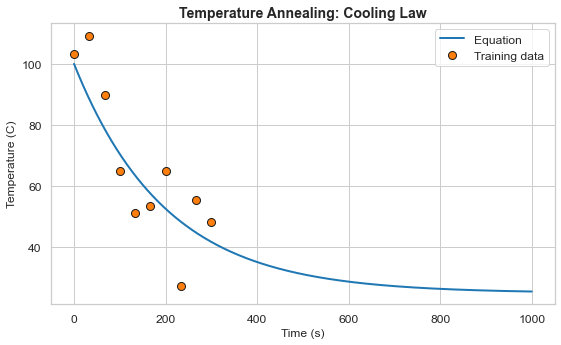

In [88]:
import torch
import numpy as np
import functools
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for better aesthetics
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

def grad(outputs, inputs):
    """Computes the partial derivative of 
    an output with respect to an input.
    Args:
        outputs: (N, 1) tensor
        inputs: (N, D) tensor
    """
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True
    )

def cooling_law(time, Tenv, T0, R):
    T = Tenv + (T0 - Tenv) * np.exp(-R * time)
    return T

Tenv = 25
T0 = 100
R = 0.005
times = np.linspace(0, 1000, 1000)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)

# Make training data
t = np.linspace(0, 300, 10)
T = eq(t) +  10 * np.random.randn(10)

plt.figure(figsize=(8, 5))
plt.plot(times, temps, label='Equation', color='tab:blue', linewidth=2)
plt.plot(t, T, 'o', label='Training data', color='tab:orange', markersize=8, markeredgecolor='k')
plt.legend(frameon=True, loc='best')
plt.ylabel('Temperature (C)', fontsize=12)
plt.xlabel('Time (s)', fontsize=12)
plt.title('Temperature Annealing: Cooling Law', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


d:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0/2000, Train Loss: 3120.3950, Val Loss: 5889.2339, LR: 0.010000
Epoch 200/2000, Train Loss: 125.4501, Val Loss: 342.3686, LR: 0.010000
Epoch 400/2000, Train Loss: 93.7568, Val Loss: 132.2268, LR: 0.010000
Epoch 600/2000, Train Loss: 84.8861, Val Loss: 69.7317, LR: 0.005000
Epoch 800/2000, Train Loss: 82.5396, Val Loss: 69.3811, LR: 0.001250
Epoch 1000/2000, Train Loss: 82.3976, Val Loss: 68.1026, LR: 0.000313
Epoch 1200/2000, Train Loss: 81.9734, Val Loss: 65.1721, LR: 0.000078
Epoch 1400/2000, Train Loss: 81.9122, Val Loss: 65.3140, LR: 0.000020
Epoch 1600/2000, Train Loss: 81.9096, Val Loss: 65.2660, LR: 0.000010
Epoch 1800/2000, Train Loss: 81.8938, Val Loss: 65.2942, LR: 0.000010
Loaded best model with validation loss: 37.669708
Mean Squared Error of NN fit: 40.710948


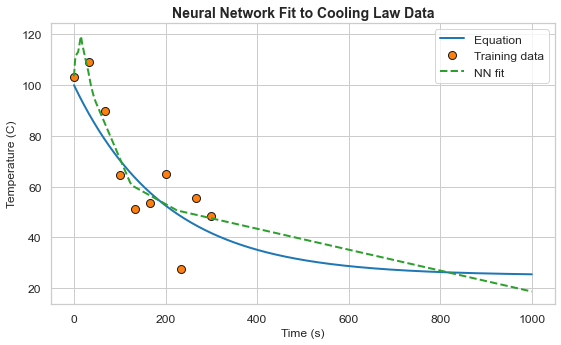

In [89]:
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import copy

# Prepare data
X_all = t.reshape(-1, 1).astype(np.float32)
y_all = T.reshape(-1, 1).astype(np.float32)

# Split into train and validation sets (e.g., 80% train, 20% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# Define a simple feedforward neural network
class FNN(nn.Module):
    def __init__(self, hidden_size=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    def forward(self, x):
        return self.net(x)

# Instantiate model, loss, and optimizer
model = FNN(hidden_size=32)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-2)

# Add a learning rate scheduler (ReduceLROnPlateau)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100, verbose=True, min_lr=1e-5
)

# Convert numpy arrays to torch tensors
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)
X_val_tensor = torch.from_numpy(X_val)
y_val_tensor = torch.from_numpy(y_val)

# Training loop with validation and best model tracking
epochs = 2000
losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    # Evaluate loss in eval mode for logging and scheduler
    model.eval()
    with torch.no_grad():
        # Training loss (for logging)
        eval_outputs = model(X_train_tensor)
        eval_loss = criterion(eval_outputs, y_train_tensor)
        losses.append(eval_loss.item())
        # Validation loss
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())
        # Step the scheduler with validation loss
        scheduler.step(val_loss)
        # Save best model
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())
    if epoch % 200 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch}/{epochs}, Train Loss: {eval_loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}")

# Load best model (with minimal validation loss)
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model with validation loss: {best_val_loss:.6f}")

# Plot fit and compute error
model.eval()
with torch.no_grad():
    t_plot = times.reshape(-1, 1).astype(np.float32)
    t_plot_tensor = torch.from_numpy(t_plot)
    pred = model(t_plot_tensor).numpy()
    # Compute mean squared error between model prediction and true values
    mse_error = np.mean((pred.flatten() - temps.flatten())**2)
    print(f"Mean Squared Error of NN fit: {mse_error:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(times, temps, label='Equation', color='tab:blue', linewidth=2)
plt.plot(t, T, 'o', label='Training data', color='tab:orange', markersize=8, markeredgecolor='k')
plt.plot(times, pred, label='NN fit', color='tab:green', linewidth=2, linestyle='--')
plt.legend(frameon=True, loc='best')
plt.ylabel('Temperature (C)', fontsize=12)
plt.xlabel('Time (s)', fontsize=12)
plt.title('Neural Network Fit to Cooling Law Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### 2 Physics-informed NNs with given physical parameter values

Epoch 0/5000, Loss: 4242.7080, LR: 0.010000
Epoch 200/5000, Loss: 2.1493, LR: 0.009037
Epoch 400/5000, Loss: 1.7343, LR: 0.006534
Epoch 600/5000, Loss: 1.6719, LR: 0.003447
Epoch 800/5000, Loss: 1.6700, LR: 0.000955
Epoch 1000/5000, Loss: 1.6699, LR: 0.000010
Epoch 1200/5000, Loss: 1.6699, LR: 0.000973
Epoch 1400/5000, Loss: 5.6854, LR: 0.003476
Epoch 1600/5000, Loss: 6.9951, LR: 0.006563
Epoch 1800/5000, Loss: 3.0465, LR: 0.009055
Epoch 2000/5000, Loss: 1.8657, LR: 0.010000
Epoch 2200/5000, Loss: 1.6838, LR: 0.009037
Epoch 2400/5000, Loss: 1.6744, LR: 0.006534
Epoch 2600/5000, Loss: 1.6716, LR: 0.003447
Epoch 2800/5000, Loss: 1.6706, LR: 0.000955
Epoch 3000/5000, Loss: 1.6705, LR: 0.000010
Epoch 3200/5000, Loss: 1.6703, LR: 0.000973
Epoch 3400/5000, Loss: 1.6692, LR: 0.003476
Epoch 3600/5000, Loss: 14.7257, LR: 0.006563
Epoch 3800/5000, Loss: 1.6032, LR: 0.009055
Epoch 4000/5000, Loss: 1.4194, LR: 0.010000
Epoch 4200/5000, Loss: 1.2833, LR: 0.009037
Epoch 4400/5000, Loss: 1.2201, LR: 

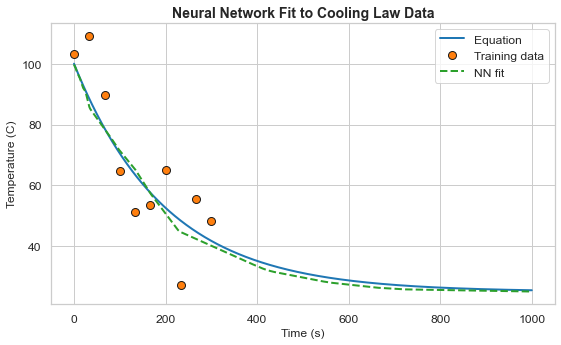

In [90]:
def physics_loss(model: torch.nn.Module):
    # Generate time points for physics loss calculation
    ts = torch.rand(50, 1) * 1000
    ts.requires_grad_(True)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    # Physics residual for Newton's law of cooling
    residual = R * (Tenv - temps) - dT
    return torch.mean(residual ** 2)

def total_loss_bn(model, X_tensor, y_tensor, alpha=1.0):
    # Data loss (MSE between model prediction and data)
    pred = model(X_tensor)
    data_loss = torch.mean((pred - y_tensor) ** 2)
    # Physics loss (from physics_loss function)
    phys_loss = physics_loss(model)
    # Total loss: weighted sum
    return data_loss + alpha * phys_loss

# Instantiate model, loss, and optimizer
model_phys = FNN(hidden_size=64)
optimizer = optim.Adam(model_phys.parameters(), lr=1e-2, weight_decay=1e-6)
# criterion = nn.MSELoss()

# Use CosineAnnealingLR as a different scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000, eta_min=1e-5, verbose=True)

# Training loop with best model tracking
epochs = 5000
losses = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(epochs):
    model_phys.train()
    optimizer.zero_grad()
    loss = total_loss_bn(model_phys, X_tensor, y_tensor, alpha=10)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    # Evaluate loss in eval mode for logging and scheduler
    model_phys.eval()
    with torch.no_grad():
        eval_outputs = model_phys(X_tensor)
        eval_loss = torch.mean((eval_outputs - y_tensor) ** 2)
        # Save best model
        if eval_loss.item() < best_val_loss:
            best_val_loss = eval_loss.item()
            best_model_state = copy.deepcopy(model_phys.state_dict())
        losses.append(eval_loss.item())
    # Step the scheduler (CosineAnnealingLR does not use eval_loss)
    scheduler.step()
    if epoch % 200 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch}/{epochs}, Loss: {eval_loss.item():.4f}, LR: {current_lr:.6f}")

# Load best model (with minimal validation loss)
if best_model_state is not None:
    model_phys.load_state_dict(best_model_state)
    print(f"Loaded best model with validation loss: {best_val_loss:.6f}")

# Plot fit
with torch.no_grad():
    model_phys.eval()
    t_plot = times.reshape(-1, 1).astype(np.float32)
    t_plot_tensor = torch.from_numpy(t_plot)
    pred = model_phys(t_plot_tensor).numpy()
    # Compute mean squared error between model prediction and true values
    mse_error = np.mean((pred.flatten() - temps.flatten())**2)
    print(f"Mean Squared Error of NN fit: {mse_error:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(times, temps, label='Equation', color='tab:blue', linewidth=2)
plt.plot(t, T, 'o', label='Training data', color='tab:orange', markersize=8, markeredgecolor='k')
plt.plot(times, pred, label='NN fit', color='tab:green', linewidth=2, linestyle='--')
plt.legend(frameon=True, loc='best')
plt.ylabel('Temperature (C)', fontsize=12)
plt.xlabel('Time (s)', fontsize=12)
plt.title('Neural Network Fit to Cooling Law Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### 3 Physics-informed NNs with unknown physical parameter values

Epoch 1/30000, Total Loss: 3756.883789
Learned R: 0.00010000001202570274
Epoch 500/30000, Total Loss: 2504.682861
Learned R: -0.001679142820648849
Epoch 1000/30000, Total Loss: 2460.762451
Learned R: -0.0017671211389824748
Epoch 1500/30000, Total Loss: 2302.978516
Learned R: -0.001598265953361988
Epoch 2000/30000, Total Loss: 2086.531738
Learned R: -0.001675305189564824
Epoch 2500/30000, Total Loss: 1832.858887
Learned R: -0.0016736732795834541
Epoch 3000/30000, Total Loss: 1485.123657
Learned R: -0.001606194768100977
Epoch 3500/30000, Total Loss: 1040.222778
Learned R: -0.0015887253684923053
Epoch 4000/30000, Total Loss: 581.255859
Learned R: -0.0013680499978363514
Epoch 4500/30000, Total Loss: 285.012665
Learned R: -0.000830948178190738
Epoch 5000/30000, Total Loss: 99.821091
Learned R: 0.00032563184504397213
Epoch 5500/30000, Total Loss: 17.689041
Learned R: 0.004307525232434273
Epoch 6000/30000, Total Loss: 10.067846
Learned R: 0.004172878339886665
Epoch 6500/30000, Total Loss: 8.0

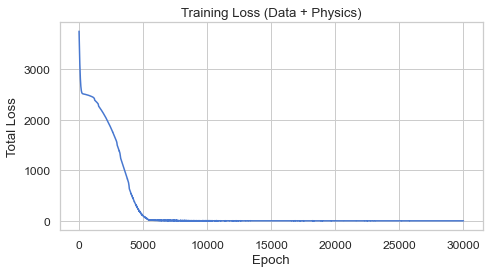

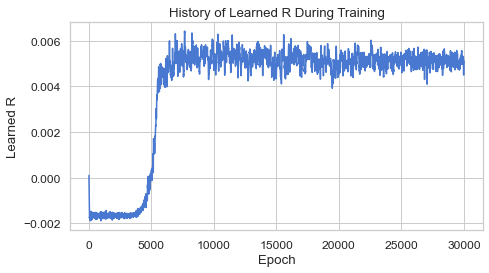

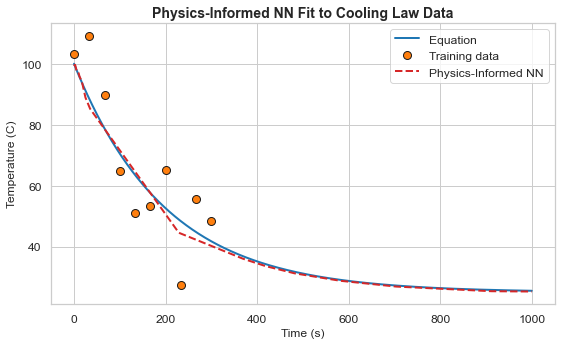

In [92]:
def physics_loss(model: torch.nn.Module):
    # Generate time points for physics loss calculation
    ts = torch.rand(50, 1) * 1000
    ts.requires_grad_(True)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    # Physics residual for Newton's law of cooling
    residual = model.R * (Tenv - temps) - dT
    return torch.mean(residual ** 2)

# Add physical loss to the original tempNN
def total_loss(model, X_tensor, y_tensor, alpha=1.0):
    # Data loss (MSE between model prediction and data)
    pred = model(X_tensor)
    data_loss = torch.mean((pred - y_tensor) ** 2)
    # Physics loss (from physics_loss function)
    phys_loss = physics_loss(model)
    # Total loss: weighted sum
    return data_loss + alpha * phys_loss


# Define a simple feedforward neural network
class FNN_unknown_params(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.net = FNN(hidden_size=hidden_size)
        self.R = nn.Parameter(torch.tensor(0.0))
    def forward(self, x):
        return self.net(x)

# Instantiate the model
model_phys = FNN_unknown_params()

# Set up optimizer
optimizer = torch.optim.Adam(model_phys.parameters(), lr=1e-4, weight_decay=1e-3)

# Training loop with physics-informed loss
n_epochs = 30000
loss_history = []
R_history = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    loss = total_loss(model_phys, X_tensor, y_tensor, alpha=10)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    R_history.append(model_phys.R.item())
    if (epoch+1) % 500 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Total Loss: {loss.item():.6f}")
        # Print the learned value of R
        print(f"Learned R: {model_phys.R.item()}")

# Plot the loss history
plt.figure(figsize=(7,4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Training Loss (Data + Physics)')
plt.tight_layout()
plt.show()

# Plot the history of model.R updates
plt.figure(figsize=(7,4))
plt.plot(R_history)
plt.xlabel('Epoch')
plt.ylabel('Learned R')
plt.title('History of Learned R During Training')
plt.tight_layout()
plt.show()

# Plot the fit of the physics-informed NN
t_plot = times.reshape(-1, 1).astype(np.float32)
t_plot_tensor = torch.from_numpy(t_plot)
pred_phys = model_phys(t_plot_tensor).detach().numpy()

plt.figure(figsize=(8, 5))
plt.plot(times, temps, label='Equation', color='tab:blue', linewidth=2)
plt.plot(t, T, 'o', label='Training data', color='tab:orange', markersize=8, markeredgecolor='k')
plt.plot(times, pred_phys, label='Physics-Informed NN', color='tab:red', linewidth=2, linestyle='--')
plt.legend(frameon=True, loc='best')
plt.ylabel('Temperature (C)', fontsize=12)
plt.xlabel('Time (s)', fontsize=12)
plt.title('Physics-Informed NN Fit to Cooling Law Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
